In [11]:
import msprime 
import dpluspy 
import numpy as np
import pickle
import demes

In [12]:
naive_reps = []
for rep in range(100):
    with open(f"stats/naive_rep_{rep}_stats.pkl", "rb") as fin:
        naive_reps.append(pickle.load(fin))

method_0_reps = []
for rep in range(100):
    with open(f"stats/method_0_rep_{rep}_stats.pkl", "rb") as fin:
        method_0_reps.append(pickle.load(fin))

method_1_reps = []
for rep in range(100):
    with open(f"stats/method_1_rep_{rep}_stats.pkl", "rb") as fin:
        method_1_reps.append(pickle.load(fin))

bins = np.logspace(-6, -2, 17) 
pop_ids = ["PopX", "PopY"]

In [13]:
model = dpluspy.inference.compute_bin_stats(
    "graph.yaml", bins=bins, u=1.1525e-8, sampled_demes=pop_ids)

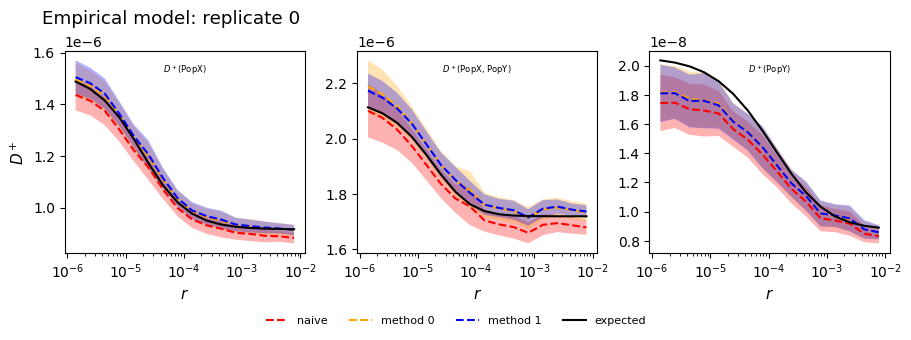

In [14]:
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_reps[0]["means"], method_0_reps[0]["means"], method_1_reps[0]["means"]],
    varcovs=[naive_reps[0]["varcovs"], method_0_reps[0]["varcovs"], method_1_reps[0]["varcovs"]],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["red", "orange", "blue", "black"],
    out="figures/figure_1.pdf",
    title="Empirical model: replicate 0",
    labels=["naive", "method 0", "method 1", "expected"]
)

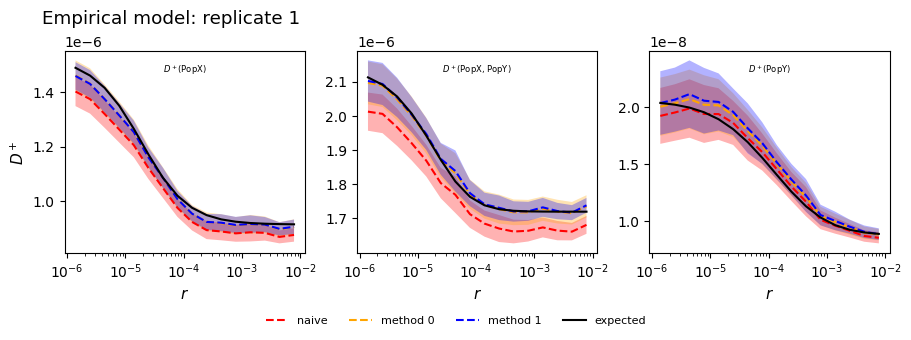

In [15]:
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_reps[1]["means"], method_0_reps[1]["means"], method_1_reps[1]["means"]],
    varcovs=[naive_reps[1]["varcovs"], method_0_reps[1]["varcovs"], method_1_reps[1]["varcovs"]],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["red", "orange", "blue", "black"],
    out="figures/figure_2.pdf",
    title="Empirical model: replicate 1",
    labels=["naive", "method 0", "method 1", "expected"]
)

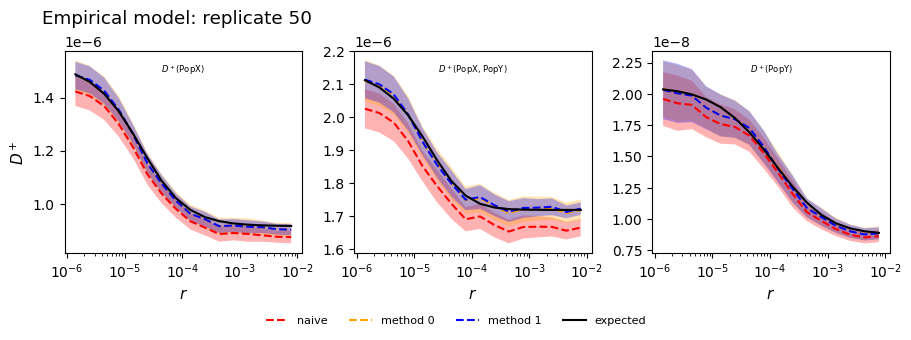

In [16]:
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_reps[50]["means"], method_0_reps[50]["means"], method_1_reps[50]["means"]],
    varcovs=[naive_reps[50]["varcovs"], method_0_reps[50]["varcovs"], method_1_reps[50]["varcovs"]],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["red", "orange", "blue", "black"],
    out="figures/figure_3.pdf",
    title="Empirical model: replicate 50",
    labels=["naive", "method 0", "method 1", "expected"]
)

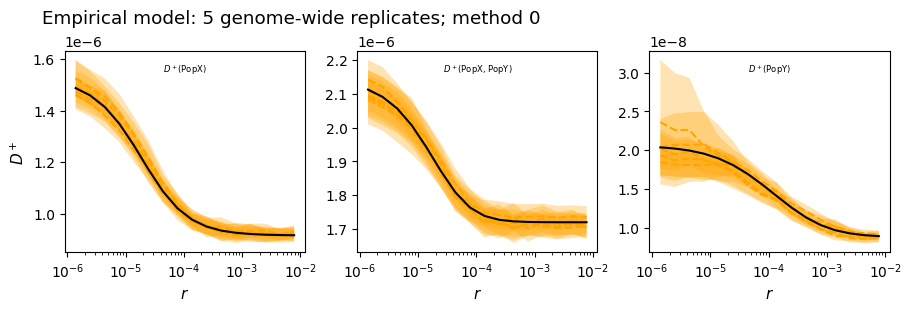

In [17]:
dpluspy.plotting.plot_D_plus_curves(
    means=[method_0_reps[i]["means"] for i in range(5, 10)],
    varcovs=[method_0_reps[i]["varcovs"] for i in range(5, 10)],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["orange"] * 5 + ["black"],
    out="figures/figure_5.pdf",
    title="Empirical model: 5 genome-wide replicates; method 0",
    labels=None
)

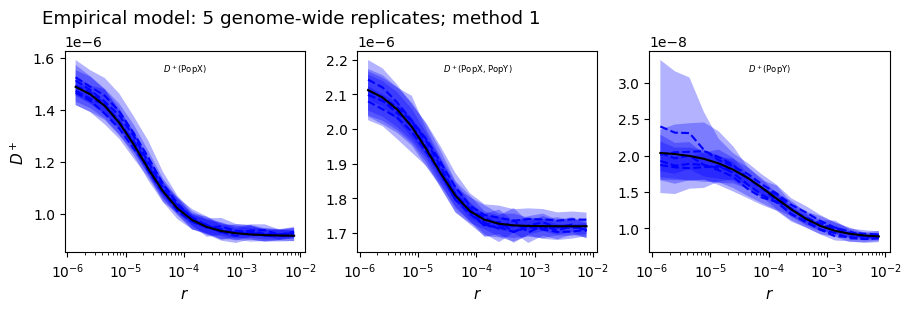

In [18]:
dpluspy.plotting.plot_D_plus_curves(
    means=[method_1_reps[i]["means"] for i in range(5, 10)],
    varcovs=[method_1_reps[i]["varcovs"] for i in range(5, 10)],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["blue"] * 5 + ["black"],
    out="figures/figure_5.pdf",
    title="Empirical model: 5 genome-wide replicates; method 1",
    labels=None
)

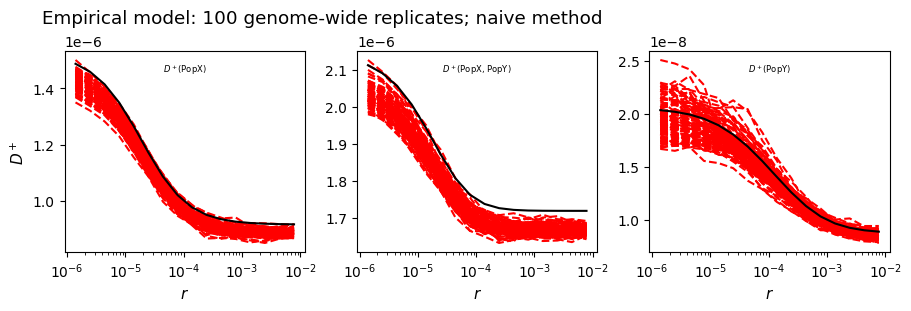

In [19]:
fake_varcovs = [[v * 0 for v in naive_reps[0]["varcovs"]]]
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_reps[i]["means"] for i in range(100)],
    varcovs=fake_varcovs * 100,
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["red"] * 100 + ["black"],
    out="figures/figure_6.pdf",
    labels=None,
    title="Empirical model: 100 genome-wide replicates; naive method"
)

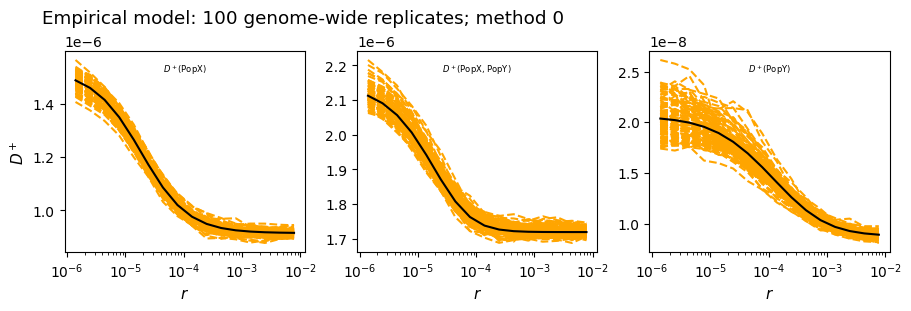

In [20]:
dpluspy.plotting.plot_D_plus_curves(
    means=[method_0_reps[i]["means"] for i in range(100)],
    varcovs=fake_varcovs * 100,
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["orange"] * 100 + ["black"],
    out="figures/figure_7.pdf",
    labels=None,
    title="Empirical model: 100 genome-wide replicates; method 0"
)

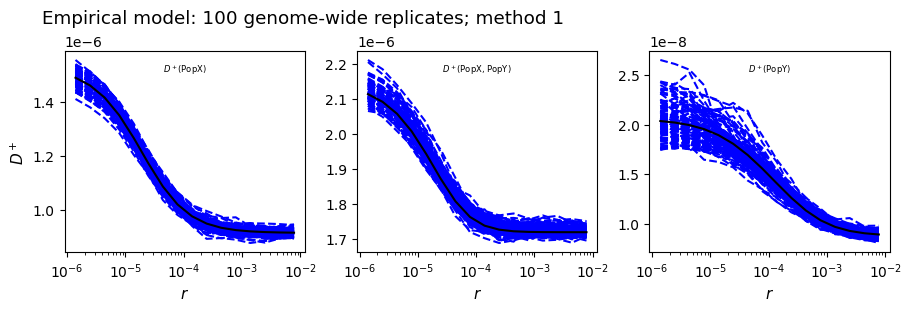

In [22]:
dpluspy.plotting.plot_D_plus_curves(
    means=[method_1_reps[i]["means"] for i in range(100)],
    varcovs=fake_varcovs * 100,
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["blue"] * 100 + ["black"],
    out="figures/figure_8.pdf",
    labels=None,
    title="Empirical model: 100 genome-wide replicates; method 1"
)

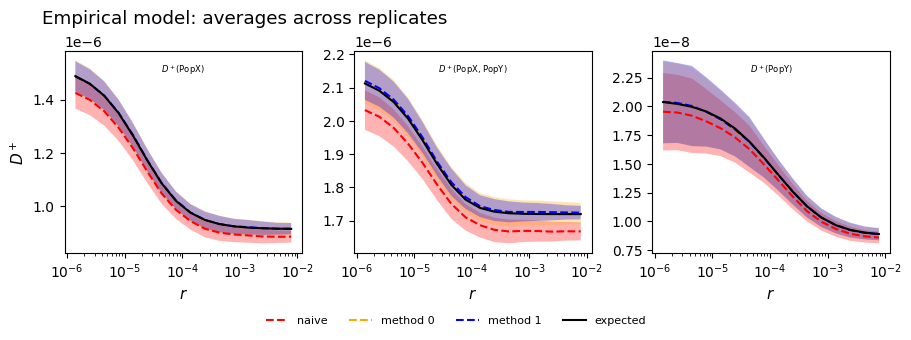

In [23]:
naive_aggrmeans = [x for x in np.mean([naive_reps[i]["means"] for i in range(100)], axis=0)]
method_0_aggrmeans = [x for x in np.mean([method_0_reps[i]["means"] for i in range(100)], axis=0)]
method_1_aggrmeans = [x for x in np.mean([method_1_reps[i]["means"] for i in range(100)], axis=0)]
naive_aggrcovs = [x for x in np.mean([naive_reps[i]["varcovs"] for i in range(100)], axis=0)]
method_0_aggrcovs = [x for x in np.mean([method_0_reps[i]["varcovs"] for i in range(100)], axis=0)]
method_1_aggrcovs = [x for x in np.mean([method_1_reps[i]["varcovs"] for i in range(100)], axis=0)]

dpluspy.plotting.plot_D_plus_curves(
    means=[naive_aggrmeans, method_0_aggrmeans, method_1_aggrmeans],
    varcovs=[naive_aggrcovs, method_0_aggrcovs, method_1_aggrcovs],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["red", "orange", "blue", "black"],
    labels=["naive", "method 0", "method 1", "expected"],
    out="figures/figure_9.pdf",
    title="Empirical model: averages across replicates",
)

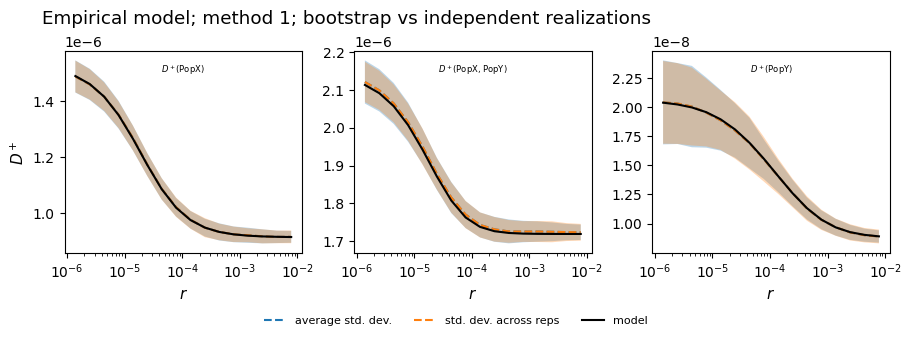

In [24]:
# plot the variance across runs
method_1_rep_stds = np.std([method_1_reps[i]["means"] for i in range(100)], axis=0) ** 2

method_1_rep_vars = []
for std in method_1_rep_stds:
    arr = np.zeros((3, 3))
    arr[[0, 1, 2], [0, 1, 2]] = std
    method_1_rep_vars.append(arr)

dpluspy.plotting.plot_D_plus_curves(
    means=[method_1_aggrmeans, method_1_aggrmeans],
    varcovs=[method_1_aggrcovs, method_1_rep_vars],
    bins=bins,
    pop_ids=pop_ids,
    models=model,
    ax_size=3,
    colors=["tab:blue", "tab:orange", "black"],
    out="figures/figure_10.pdf",
    title="Empirical model; method 1; bootstrap vs independent realizations",
    labels=["average std. dev.", "std. dev. across reps", "model"]
)